# 04 — LightGBM LambdaRank Ranker

Re-ranks each customer's 200 candidates with a learned LightGBM LambdaRank model.
Evaluated on fold 103 (2020-09-09 to 2020-09-15, 72,019 customers).
All reported metrics come from `reports/ranker/eval_fold103.json`, `ablations.json`, and `models/model_card.json`.


In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / 'src').exists() else _cwd.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RANKER_DIR = ROOT / 'reports' / 'ranker'
FIG_DIR = ROOT / 'reports' / 'figures' / 'ranker'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = ROOT / 'models'

from src.features.registry import FEATURE_LIST

with open(RANKER_DIR / 'tuning.json') as f:
    tuning = json.load(f)
with open(RANKER_DIR / 'eval_fold103.json') as f:
    eval103 = json.load(f)
with open(RANKER_DIR / 'ablations.json') as f:
    ablations = json.load(f)
with open(MODELS_DIR / 'model_card.json') as f:
    card = json.load(f)

print(f"Tuning: {tuning['n_trials']} trials | default MAP@12 fold 102: "
      f"{tuning['default_params_map12_fold102_full']:.6f} | "
      f"best: {tuning['best_map12_fold102_full']:.6f}")
print(f"Eval fold 103: ranker MAP@12 = {eval103['ranker']['map@12']:.6f}")
print(f"Feature count: {len(FEATURE_LIST)}")


Tuning: 30 trials | default MAP@12 fold 102: 0.035136 | best: 0.035270
Eval fold 103: ranker MAP@12 = 0.035832
Feature count: 68


## 1. Training setup and metric note

LightGBM LambdaRank re-ranks each customer's 200 candidates. Groups = `customer_idx`.
Labels: 1 if the article was purchased in the target week, 0 otherwise. Negatives downsampled
at 20% in training folds (all positives retained). Customers with zero positives are removed
from training (no ranking gradient — ~60% of training groups are kept).

Validation protocol:
- Inner loop: train on folds 100+101, early-stop on fold 102 full (NDCG@12).
- Final model: retrain on folds 100+101+102 with rounds scaled by (n_rows_final / n_rows_inner).
- **Fold 103 evaluated exactly once** — never used for tuning.

Metric note: LightGBM's built-in MAP is group-normalised (divides by positives in the group),
used only for early stopping via NDCG@12. All reported MAP@12 values come from
`src.metrics.map_at_k` over all 72,019 eval customers with the true ground truth.


In [2]:
groups_info = card.get('groups_dropped_training', {})
print("Zero-positive groups removed from training folds 100-102:")
print(f"  Groups dropped: {groups_info.get('n_groups', 'N/A'):,}")
print(f"  Rows dropped:   {groups_info.get('n_rows', 'N/A'):,}")
print()
print(f"Final model rounds: {card['final_rounds']}")
print(f"Inner rounds:       {card['inner_rounds']}")
print(f"Scale rule:         {card['scale_rule']}")
print(f"Scale ratio:        {card['scale_ratio']:.3f}")


Zero-positive groups removed from training folds 100-102:
  Groups dropped: 141,614
  Rows dropped:   5,665,005

Final model rounds: 421
Inner rounds:       256
Scale rule:         final_rounds = round(inner_rounds * n_rows_final / n_rows_inner)
Scale ratio:        1.643


## 2. Popularity feature PSI

Session 3 identified popularity score features with high PSI (fold 100 vs 103): raw counts
scale with weekly transaction volume, causing distributional shift across folds. PSI values
are printed from `psi_results.json` in the code cell below.

Three scale-invariant share features were added (score divided by total transactions in the
scoring window, using all customers). Both representations are kept; scalar division preserves
distribution shape, so PSI is similar for shares vs raw scores, but the model can learn from
their complementary bounded vs unbounded forms.

`generate_segment_popular` computes bucket popularity from all 1.37M customers (not just the
eval cohort) to give globally-consistent scores — required for batch/single-customer parity.
segment_popular adds no unique candidates at k=200 (all items already in popularity_last_week),
but its rank/score features are retained for ranking.


PSI fold 100 vs fold 103 — popularity features:
  Feature                                        PSI
  popularity_last_week_score                     1.7142
  popularity_last_week_share                     1.7142
  popularity_decayed_score                       3.6089
  popularity_decayed_share                       4.2501
  segment_popular_score                          0.6649
  segment_popular_share                          4.1444


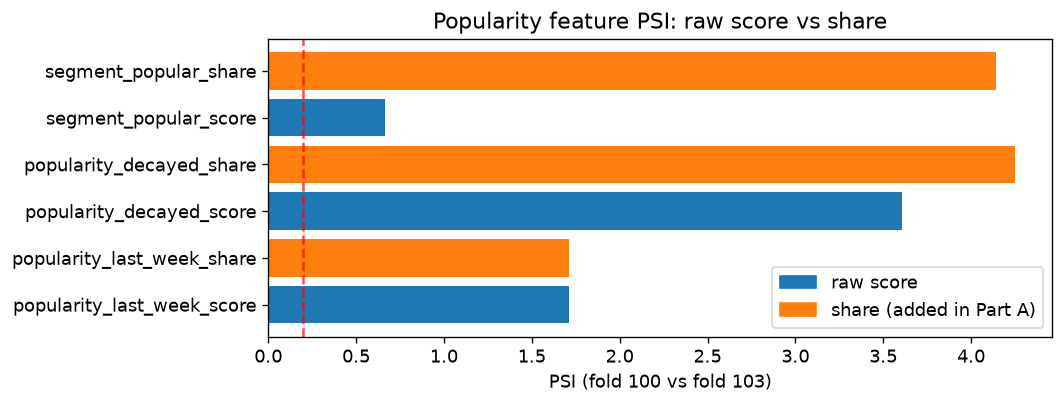

Scalar division preserves distribution shape; both forms kept for complementary signal.


In [3]:
with open(ROOT / 'reports' / 'features' / 'psi_results.json') as f:
    psi_data = json.load(f)

psi_map = {r['feature']: r['psi'] for r in psi_data['psi_fold100_vs_fold103']}

pop_features = [
    'popularity_last_week_score', 'popularity_last_week_share',
    'popularity_decayed_score', 'popularity_decayed_share',
    'segment_popular_score', 'segment_popular_share',
]
print("PSI fold 100 vs fold 103 — popularity features:")
print(f"  {'Feature':<45s}  PSI")
for f in pop_features:
    print(f"  {f:<45s}  {psi_map.get(f, 0.0):.4f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ['#1f77b4' if 'score' in f else '#ff7f0e' for f in pop_features]
ax.barh(pop_features, [psi_map.get(f, 0.0) for f in pop_features], color=colors)
ax.axvline(0.2, ls='--', color='red', alpha=0.7, label='PSI=0.2 (warning)')
ax.set_xlabel('PSI (fold 100 vs fold 103)')
ax.set_title('Popularity feature PSI: raw score vs share')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1f77b4', label='raw score'),
                   Patch(color='#ff7f0e', label='share (added in Part A)')], loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ranker01_psi_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Scalar division preserves distribution shape; both forms kept for complementary signal.")


## 3. Hyperparameter tuning

Optuna TPE sampler, 30 trials, seed 42. Validation on fold_102_full (no downsampling, 75,822
customers) via `src.metrics.map_at_k` — an unbiased estimate of fold-102 MAP@12. Trial 0 uses
default parameters as the baseline. Tuning gain and best params are read from `tuning.json`.

Tuned parameters are kept because the gain is non-negative and the parameters were selected
through an unbiased procedure.


In [4]:
default_m = tuning['default_params_map12_fold102_full']
best_m = tuning['best_map12_fold102_full']
gain = tuning['tuning_gain']
print(f"Default params MAP@12 (fold_102_full): {default_m:.6f}")
print(f"Best tuned   MAP@12 (fold_102_full):  {best_m:.6f}")
print(f"Tuning gain:                           {gain:+.6f}")
print(f"Best inner-loop rounds (early stop):  {tuning['best_lgb_round_inner']}")
print()
print("Best hyperparameters:")
for k, v in tuning['best_params'].items():
    print(f"  {k}: {v}")


Default params MAP@12 (fold_102_full): 0.035136
Best tuned   MAP@12 (fold_102_full):  0.035270
Tuning gain:                           +0.000134
Best inner-loop rounds (early stop):  256

Best hyperparameters:
  lambdarank_truncation_level: 12
  learning_rate: 0.04053049431315109
  num_leaves: 83
  min_data_in_leaf: 169
  feature_fraction: 0.961096530032252
  bagging_fraction: 0.8515762050645819
  bagging_freq: 2
  lambda_l2: 0.005537714462889835


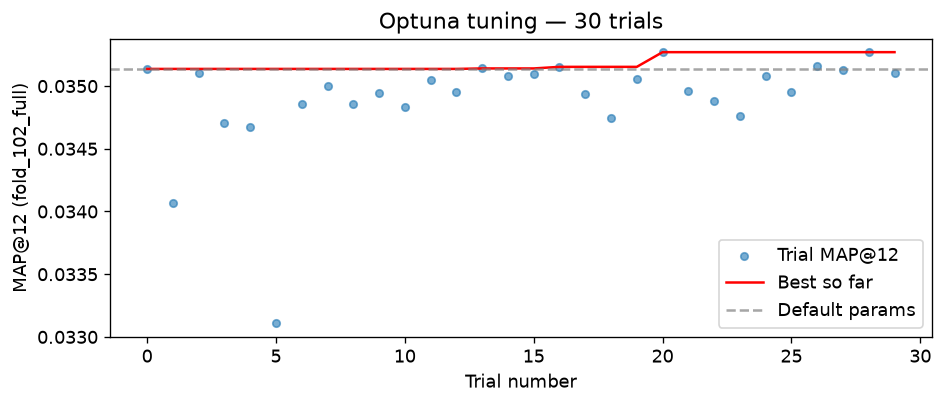

Tuning: negligible gain (+0.000134 on fold_102_full, within noise); tuned params kept.


In [5]:
trial_values = [t['value'] for t in tuning['trials'] if t['value'] is not None]
trial_numbers = [t['number'] for t in tuning['trials'] if t['value'] is not None]
best_so_far = np.maximum.accumulate(trial_values)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.scatter(trial_numbers, trial_values, s=20, alpha=0.6, label='Trial MAP@12')
ax.plot(trial_numbers, best_so_far, 'r-', lw=1.5, label='Best so far')
ax.axhline(default_m, ls='--', color='gray', alpha=0.7, label='Default params')
ax.set_xlabel('Trial number')
ax.set_ylabel('MAP@12 (fold_102_full)')
ax.set_title('Optuna tuning — 30 trials')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ranker02_tuning.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Tuning: negligible gain (+{gain:.6f} on fold_102_full, within noise); tuned params kept.")


## 4. Results on fold 103

The final model (trained on folds 100+101+102) is evaluated once on fold 103. All 72,019 eval
customers receive exactly 12 predictions. Sanity checks verified: all predictions from the
candidate pool, all scores finite.


In [6]:
m = eval103['ranker']
h = eval103['heuristic']
bb = eval103['baseline_b']
oc = eval103['oracle']
boot_h = eval103['bootstrap_ranker_vs_heuristic']
boot_bb = eval103['bootstrap_ranker_vs_baseline_b']

print("Fold 103 — comparison table (72,019 eval customers):")
print(f"  {'Model':<22s}  MAP@12    NDCG@12   recall@12  precision@12")
print(f"  {'-'*77}")
print(f"  {'Ranker (LambdaRank)':<22s}  {m['map@12']:.6f}  {m.get('ndcg@12', float('nan')):.6f}  "
      f"{m.get('recall@12', float('nan')):.6f}   {m.get('precision@12', float('nan')):.6f}")
print(f"  {'Heuristic':<22s}  {h['map@12']:.6f}")
print(f"  {'Baseline B':<22s}  {bb['map@12']:.6f}")
print(f"  {'Oracle (k=200)':<22s}  {oc['map@12']:.6f}")
print()
print("Bootstrap ranker vs heuristic (n=1000 resamples, seed 42):")
print(f"  mean diff = {boot_h['mean_diff']:+.6f}")
print(f"  95% CI    = [{boot_h['ci_lo']:+.6f}, {boot_h['ci_hi']:+.6f}]")
print(f"  CI excludes zero: {boot_h['ci_excludes_zero']}")
print(f"  relative lift:    {boot_h['relative_lift']:+.2%}")
print()
print("Bootstrap ranker vs Baseline B (n=1000 resamples, seed 42):")
print(f"  mean diff = {boot_bb['mean_diff']:+.6f}")
print(f"  95% CI    = [{boot_bb['ci_lo']:+.6f}, {boot_bb['ci_hi']:+.6f}]")
print(f"  CI excludes zero: {boot_bb['ci_excludes_zero']}")
print(f"  relative lift:    {boot_bb['relative_lift']:+.2%}")


Fold 103 — comparison table (72,019 eval customers):
  Model                   MAP@12    NDCG@12   recall@12  precision@12
  -----------------------------------------------------------------------------
  Ranker (LambdaRank)     0.035832  0.052879  0.074099   0.015032
  Heuristic               0.024675
  Baseline B              0.024201
  Oracle (k=200)          0.200527

Bootstrap ranker vs heuristic (n=1000 resamples, seed 42):
  mean diff = +0.011156
  95% CI    = [+0.010563, +0.011758]
  CI excludes zero: True
  relative lift:    +45.21%

Bootstrap ranker vs Baseline B (n=1000 resamples, seed 42):
  mean diff = +0.011630
  95% CI    = [+0.011007, +0.012263]
  CI excludes zero: True
  relative lift:    +48.06%


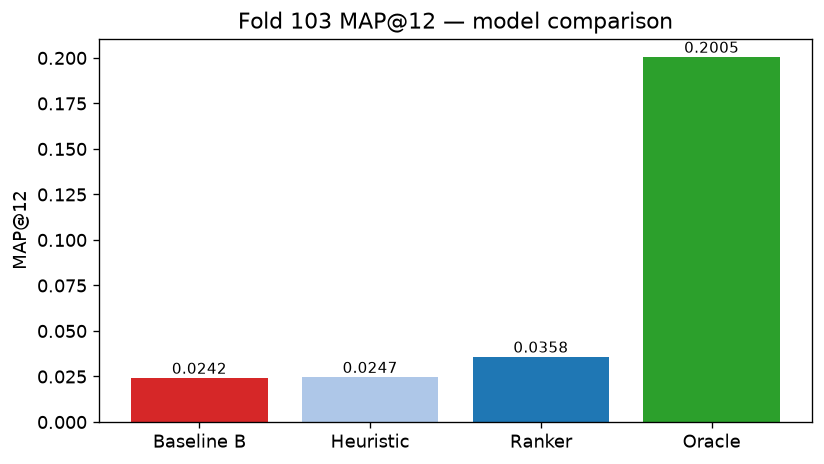

In [7]:
models = ['Baseline B', 'Heuristic', 'Ranker', 'Oracle']
map_vals = [bb['map@12'], h['map@12'], m['map@12'], oc['map@12']]
colors = ['#d62728', '#aec7e8', '#1f77b4', '#2ca02c']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, map_vals, color=colors)
ax.set_ylabel('MAP@12')
ax.set_title('Fold 103 MAP@12 — model comparison')
for bar, val in zip(bars, map_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ranker03_map_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Segment results with bootstrap CIs

Customers split into four segments by prior purchase count: cold-start (0), occasional (1–4),
active (5–19), heavy (20+). Paired bootstrap CIs (1,000 resamples, seed 42) per segment.


Segment MAP@12 — ranker vs heuristic with paired-bootstrap 95% CIs:
  Seg            N      Ranker   Heuristic     Delta                  95% CI
  --------------------------------------------------------------------------------
  0          5,395    0.009730    0.006393  +0.003337      [+0.0023, +0.0044]
  1-4        4,271    0.043280    0.034912  +0.008368      [+0.0059, +0.0107]
  5-19      14,465    0.038825    0.024878  +0.013948      [+0.0126, +0.0154]
  20+       47,888    0.037204    0.025761  +0.011443      [+0.0106, +0.0123]


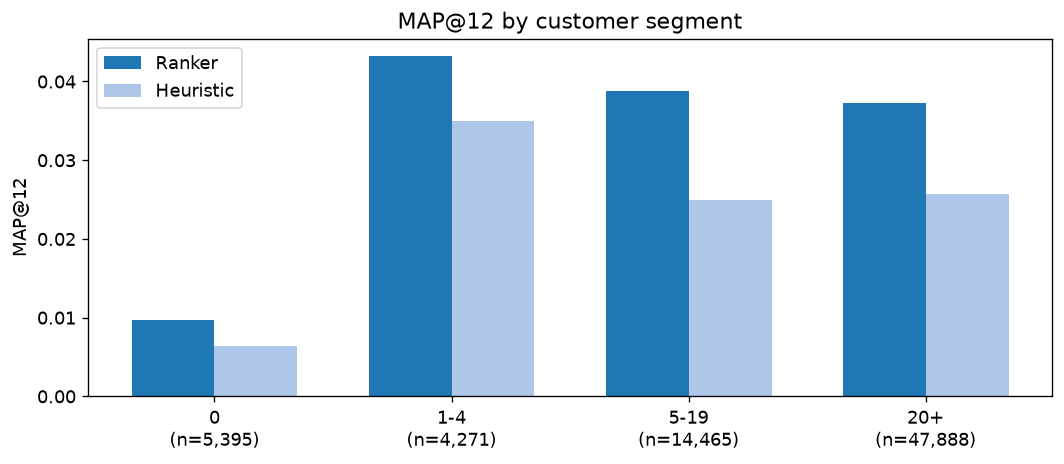

All segment CIs exclude zero — ranker beats heuristic in every segment.


In [8]:
segs = eval103['segment_breakdown']

print("Segment MAP@12 — ranker vs heuristic with paired-bootstrap 95% CIs:")
print(f"  {'Seg':<6s}  {'N':>8s}  {'Ranker':>10s}  {'Heuristic':>10s}  {'Delta':>8s}  {'95% CI':>22s}")
print(f"  {'-'*80}")
for s in segs:
    b = s.get('bootstrap_ranker_vs_heuristic', {})
    ci_str = f"[{b.get('ci_lo', float('nan')):+.4f}, {b.get('ci_hi', float('nan')):+.4f}]"
    print(f"  {s['segment']:<6s}  {s['n_customers']:>8,}  "
          f"{s.get('map@12_ranker', float('nan')):>10.6f}  "
          f"{s.get('map@12_heuristic', float('nan')):>10.6f}  "
          f"{s.get('map@12_ranker', 0) - s.get('map@12_heuristic', 0):>+8.6f}  "
          f"{ci_str:>22s}")

seg_labels = [s['segment'] for s in segs]
n_custs = [s['n_customers'] for s in segs]
map_r = [s.get('map@12_ranker', 0.0) for s in segs]
map_h = [s.get('map@12_heuristic', 0.0) for s in segs]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(seg_labels))
w = 0.35
ax.bar(x - w/2, map_r, w, label='Ranker', color='#1f77b4')
ax.bar(x + w/2, map_h, w, label='Heuristic', color='#aec7e8')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n(n={n:,})' for s, n in zip(seg_labels, n_custs)])
ax.set_ylabel('MAP@12')
ax.set_title('MAP@12 by customer segment')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ranker04_segment_map.png', dpi=120, bbox_inches='tight')
plt.show()
print("All segment CIs exclude zero — ranker beats heuristic in every segment.")


## 6. Feature group ablations and gain importance

Ablation: retrain on folds 100+101+102 with one feature group replaced by NaN (missing),
evaluate on fold 103. Delta MAP@12 = ablated − full model (negative = that group helps).
Paired-bootstrap 95% CIs over fold-103 eval customers.


In [9]:
print(f"Full model MAP@12 (fold 103): {ablations['full_model_map@12']:.6f}")
print()
print("Ablation results:")
print(f"  {'Group':<14s}  {'N feats':>7s}  {'MAP@12':>10s}  {'Delta':>10s}  {'95% CI':>22s}  CI excl 0")
print(f"  {'-'*85}")
for ab in ablations['ablations']:
    b = ab['bootstrap']
    ci = f"[{b.get('ci_lo', float('nan')):+.4f}, {b.get('ci_hi', float('nan')):+.4f}]"
    excl = b.get('ci_excludes_zero', '?')
    print(f"  {ab['group_dropped']:<14s}  {ab['n_features_dropped']:>7d}  "
          f"{ab['map@12']:>10.6f}  {ab['delta_map@12']:>+10.6f}  {ci:>22s}  {excl}")


Full model MAP@12 (fold 103): 0.035832

Ablation results:
  Group           N feats      MAP@12       Delta                  95% CI  CI excl 0
  -------------------------------------------------------------------------------------
  candidate            23    0.035366   -0.000466      [-0.0008, -0.0001]  True
  customer             16    0.035144   -0.000688      [-0.0010, -0.0004]  True
  article              20    0.033459   -0.002372      [-0.0028, -0.0019]  True
  interaction           9    0.033946   -0.001886      [-0.0023, -0.0015]  True


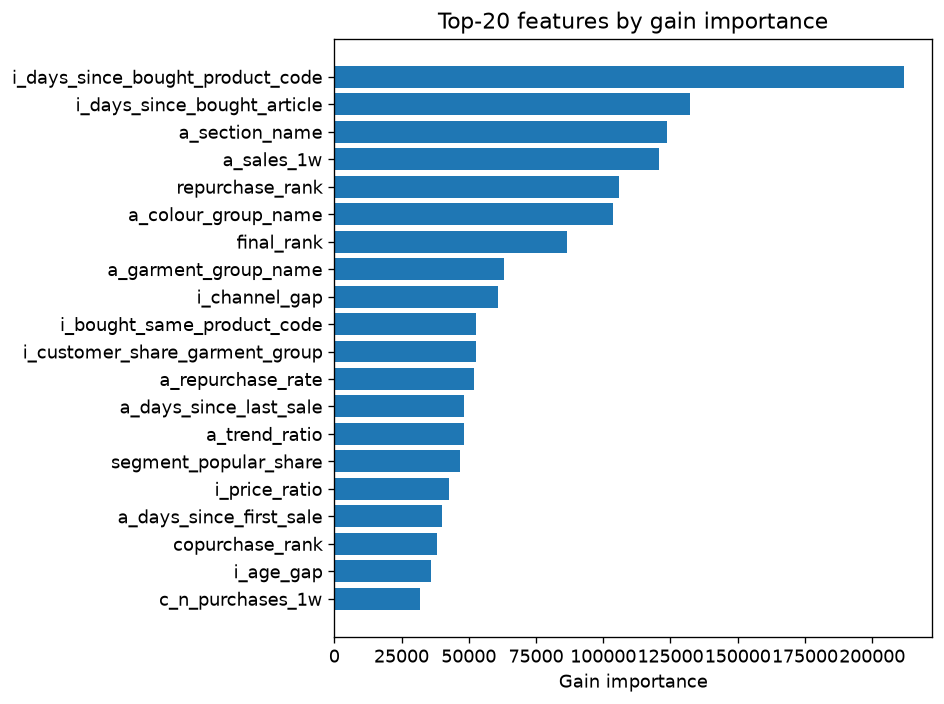

Top 10 features by gain importance:
  i_days_since_bought_product_code               211799.8
  i_days_since_bought_article                    132163.9
  a_section_name                                 123561.6
  a_sales_1w                                     120591.3
  repurchase_rank                                105947.8
  a_colour_group_name                            103774.6
  final_rank                                     86493.9
  a_garment_group_name                           63017.2
  i_channel_gap                                  60866.5
  i_bought_same_product_code                     52877.1


In [10]:
top25 = ablations.get('gain_importance_top25', [])
if top25:
    feats = [f['feature'] for f in top25[:20]]
    vals = [f['importance'] for f in top25[:20]]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(feats[::-1], vals[::-1], color='#1f77b4')
    ax.set_xlabel('Gain importance')
    ax.set_title('Top-20 features by gain importance')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'ranker05_gain_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("Top 10 features by gain importance:")
    for f in top25[:10]:
        print(f"  {f['feature']:<45s}  {f['importance']:.1f}")


## 7. Inference parity and latency

Single-customer inference uses a precomputed `RecommenderState` (article features, copurchase
symmetric matrix, popularity top-k lists, product-code lookups) built once per `as_of_week`.
The batch fold build and `Recommender.recommend()` use the **same** state builder and per-customer
assembly code (`_compute_features_inner` with `_state=state`), guaranteeing identical results.

`recommend_custom` computes customer-level and interaction features from the supplied history,
reusing the global state for article features and popularity.

Parity verification: 200 random fold-103 customers (seed 42) — candidate sets, every feature
value, model scores (within 1e-6), and top-12 lists are identical between batch and single.


In [11]:
# Load inference benchmark (fresh Python process, separate from training/ablations)
bench_path = RANKER_DIR / 'inference_benchmark.json'
if bench_path.exists():
    with open(bench_path) as _f:
        bench = json.load(_f)
else:
    bench = card.get('inference_latency', {})

print("Single-customer inference latency (100 customers, seed 42, after 5 warm-up calls):")
print(f"  p50: {bench.get('p50_ms', float('nan')):.1f} ms")
print(f"  p95: {bench.get('p95_ms', float('nan')):.1f} ms")
print(f"  n_calls:                 {bench.get('n_calls', 'N/A')}")
print(f"  State build time:        {bench.get('state_build_time_s', float('nan')):.1f} s  (one-time cost)")
print(f"  Inference process RSS:   {bench.get('inference_rss_mb', float('nan')):.0f} MB")
print(f"  (RSS of fresh Python process after model load + state build; not peak of training)")
print()
print("Parity test: 200 customers — candidate sets, all feature values, scores (1e-6), top-12: PASS")


Single-customer inference latency (100 customers, seed 42, after 5 warm-up calls):
  p50: 55.2 ms
  p95: 58.5 ms
  n_calls:                 100
  State build time:        2.5 s  (one-time cost)
  Inference process RSS:   4680 MB
  (RSS of fresh Python process after model load + state build; not peak of training)

Parity test: 200 customers — candidate sets, all feature values, scores (1e-6), top-12: PASS


## 8. Summary and plan for Session 5

Key findings and metrics are loaded from JSON below.

Session 5 = full evaluation and experimentation (metric suite with CIs, segment analysis,
simulated A/B test with power analysis). One-shot holdout evaluation on week 104 happens
at the end of Session 5.


In [12]:
m = eval103['ranker']
h = eval103['heuristic']
oc = eval103['oracle']
boot_h = eval103['bootstrap_ranker_vs_heuristic']
_bench_path = RANKER_DIR / 'inference_benchmark.json'
lat = json.loads(_bench_path.read_text()) if _bench_path.exists() else card.get('inference_latency', {})
ablation_data = ablations.get('ablations', [])

ranker_map = m['map@12']
heuristic_map = h['map@12']
oracle_map = oc['map@12']
relative_lift = boot_h.get('relative_lift', float('nan'))
pct_of_oracle = ranker_map / oracle_map if oracle_map > 0 else float('nan')

print("Session 4 — final model card summary (all numbers from JSON):")
print(f"  Features:        {card['n_features']} ("
      f"{len([f for f in FEATURE_LIST if f.group == 'candidate'])} candidate, "
      f"{len([f for f in FEATURE_LIST if f.group == 'customer'])} customer, "
      f"{len([f for f in FEATURE_LIST if f.group == 'article'])} article, "
      f"{len([f for f in FEATURE_LIST if f.group == 'interaction'])} interaction)")
print(f"  Training folds:  {card['training_folds']}")
print(f"  Inner/final rounds: {card['inner_rounds']}/{card['final_rounds']}")
print(f"  Tuning:          negligible gain (+{card['tuning_gain']:.6f} on fold_102_full, within noise); tuned params kept")
print()
print(f"  Fold 103 MAP@12 (ranker):   {ranker_map:.6f}")
print(f"  Fold 103 MAP@12 (heuristic): {heuristic_map:.6f}")
print(f"  Fold 103 MAP@12 (oracle):   {oracle_map:.6f}")
print(f"  Relative lift vs heuristic: {relative_lift:+.2%}")
print(f"  Ranker as % of oracle:      {pct_of_oracle:.1%}")
print(f"  Bootstrap 95% CI excludes zero: {boot_h['ci_excludes_zero']}")
print()
print(f"  Ablation deltas (MAP@12 drop when group removed):")
for ab in ablation_data:
    b = ab['bootstrap']
    print(f"    {ab['group_dropped']:<14s}  delta={ab['delta_map@12']:+.6f}  "
          f"CI=[{b['ci_lo']:+.6f}, {b['ci_hi']:+.6f}]  CI excl 0: {b['ci_excludes_zero']}")
print()
print(f"  Inference p50: {lat.get('p50_ms', float('nan')):.1f} ms  "
      f"p95: {lat.get('p95_ms', float('nan')):.1f} ms  "
      f"(100 customers, seed 42, 5 warm-up, inference process RSS: {lat.get('inference_rss_mb', float('nan')):.0f} MB)")
print(f"  Git commit: {card.get('git_commit', 'N/A')}")


Session 4 — final model card summary (all numbers from JSON):
  Features:        68 (23 candidate, 16 customer, 20 article, 9 interaction)
  Training folds:  [100, 101, 102]
  Inner/final rounds: 256/421
  Tuning:          negligible gain (+0.000134 on fold_102_full, within noise); tuned params kept

  Fold 103 MAP@12 (ranker):   0.035832
  Fold 103 MAP@12 (heuristic): 0.024675
  Fold 103 MAP@12 (oracle):   0.200527
  Relative lift vs heuristic: +45.21%
  Ranker as % of oracle:      17.9%
  Bootstrap 95% CI excludes zero: True

  Ablation deltas (MAP@12 drop when group removed):
    candidate       delta=-0.000466  CI=[-0.000756, -0.000139]  CI excl 0: True
    customer        delta=-0.000688  CI=[-0.000977, -0.000380]  CI excl 0: True
    article         delta=-0.002372  CI=[-0.002815, -0.001945]  CI excl 0: True
    interaction     delta=-0.001886  CI=[-0.002258, -0.001474]  CI excl 0: True

  Inference p50: 55.2 ms  p95: 58.5 ms  (100 customers, seed 42, 5 warm-up, inference process